<div style="background: linear-gradient(135deg, #0f0f1a 0%, #1a1a2e 50%, #16213e 100%); padding: 40px; border-radius: 16px; font-family: monospace; border: 1px solid #00d4ff33;">
<h1 style="color:#00d4ff; font-size:2.2em; margin:0; letter-spacing:3px;"> LICENSE PLATE DEBLURRING</h1>
<h3 style="color:#888; margin:8px 0 0 0; font-weight:normal;">Advanced Deconvolution Pipeline — ESIN UIR · Spring 2026</h3>
<hr style="border-color:#00d4ff33; margin:20px 0;"/>
<p style="color:#ccc; font-size:0.95em; line-height:1.8;">
Ce projet implémente un pipeline complet de restauration d'images de plaques d'immatriculation floues par mouvement.<br> Réalisé par : DOUMI MOHAMED TAHA - LINA EL HARTI - SOUFIANE CHERKAOUI</br>
<b style='color:#00d4ff'>Méthodes :</b> Inverse naïve · Filtre de Wiener · Régularisation Tikhonov · CNN PSF Estimator (bonus)<br>
<b style='color:#00d4ff'>Métriques :</b> PSNR · SSIM · Analyse FFT · Comparaison multi-méthodes
</p>
</div>

##  Cellule 0 — Installation & Imports

In [1]:
# ── Installation des dépendances ──────────────────────────────────────────────
!pip install scikit-image torch torchvision --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
import cv2
from skimage import io, color, metrics
from skimage.draw import rectangle
from PIL import Image, ImageDraw, ImageFont
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings, os, random, math, time
from pathlib import Path
warnings.filterwarnings('ignore')

# Seed pour reproductibilité
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Environnement prêt | Device : {DEVICE}")
print(f"   NumPy {np.__version__} | PyTorch {torch.__version__} | OpenCV {cv2.__version__}")

✅ Environnement prêt | Device : cuda
   NumPy 2.0.2 | PyTorch 2.10.0+cu128 | OpenCV 4.13.0


---
##  Cellule 1 — Génération du PSF (Point Spread Function)

Le **flou de mouvement linéaire** est modélisé par un noyau (PSF) de longueur $L$ et d'angle $\theta$.

$$h[x,y] = \frac{1}{L} \cdot \mathbb{1}_{\text{segment}}(x, y, L, \theta)$$

Le flou est appliqué par convolution : $g = f * h + n$ où $n$ est un bruit gaussien.

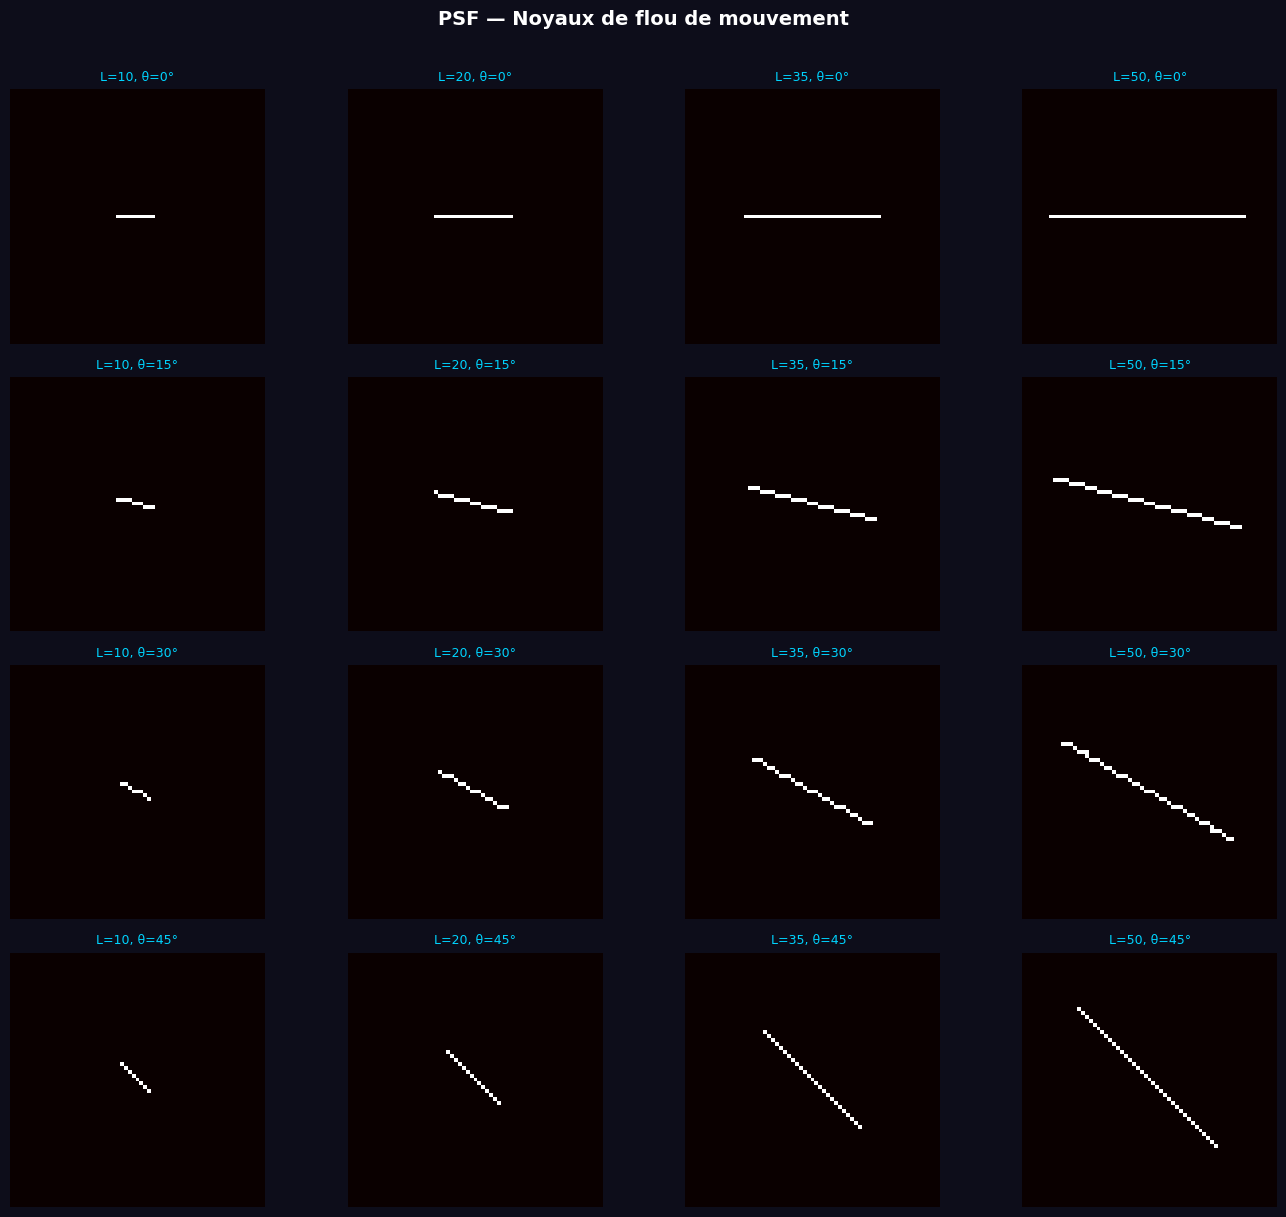

✅ PSF visualisées et sauvegardées → psf_grid.png


In [2]:
class PSFGenerator:
    """
    Génère le noyau de flou de mouvement (Point Spread Function).

    Parameters
    ----------
    length : int
        Longueur du flou en pixels.
    angle : float
        Angle du flou en degrés (0 = horizontal).
    size : int
        Taille du noyau carré (size x size).

    Returns
    -------
    kernel : np.ndarray shape (size, size), dtype float32, somme = 1
    """

    @staticmethod
    def generate(length: int, angle: float, size: int = 65) -> np.ndarray:
        """
        Génère un noyau de flou de mouvement normalisé.

        Parameters
        ----------
        length : int   — longueur du trait de flou (pixels)
        angle  : float — angle en degrés
        size   : int   — taille du kernel (doit être impair)

        Returns
        -------
        kernel : np.ndarray (size, size) float32
        """
        if size % 2 == 0:
            size += 1
        kernel = np.zeros((size, size), dtype=np.float32)
        center = size // 2
        angle_rad = np.deg2rad(angle)
        cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)

        for i in range(length):
            offset = i - length // 2
            x = int(round(center + offset * cos_a))
            y = int(round(center + offset * sin_a))
            if 0 <= x < size and 0 <= y < size:
                kernel[y, x] = 1.0

        total = kernel.sum()
        if total > 0:
            kernel /= total
        return kernel

    @staticmethod
    def visualize_psf(lengths, angles):
        """Affiche une grille de PSF pour différents paramètres."""
        fig, axes = plt.subplots(len(angles), len(lengths),
                                  figsize=(3.5 * len(lengths), 3 * len(angles)),
                                  facecolor='#0d0d1a')
        fig.suptitle('PSF — Noyaux de flou de mouvement', color='white',
                      fontsize=14, fontweight='bold', y=1.01)

        for i, angle in enumerate(angles):
            for j, length in enumerate(lengths):
                ax = axes[i][j] if len(angles) > 1 else axes[j]
                kernel = PSFGenerator.generate(length, angle, size=65)
                ax.imshow(kernel, cmap='hot', interpolation='nearest')
                ax.set_title(f'L={length}, θ={angle}°', color='#00d4ff', fontsize=9)
                ax.axis('off')
        plt.tight_layout()
        plt.savefig('psf_grid.png', dpi=120, bbox_inches='tight',
                    facecolor='#0d0d1a', edgecolor='none')
        plt.show()
        print("✅ PSF visualisées et sauvegardées → psf_grid.png")


# Démonstration
PSFGenerator.visualize_psf(
    lengths=[10, 20, 35, 50],
    angles=[0, 15, 30, 45]
)

---
##  Cellule 2 — Génération du Dataset Synthétique

On génère des plaques synthétiques réalistes, puis on les flou avec des paramètres connus.

⏳ Génération de 300 échantillons...
   50/300 ✓
   100/300 ✓
   150/300 ✓
   200/300 ✓
   250/300 ✓
   300/300 ✓
✅ Dataset généré : 300 paires


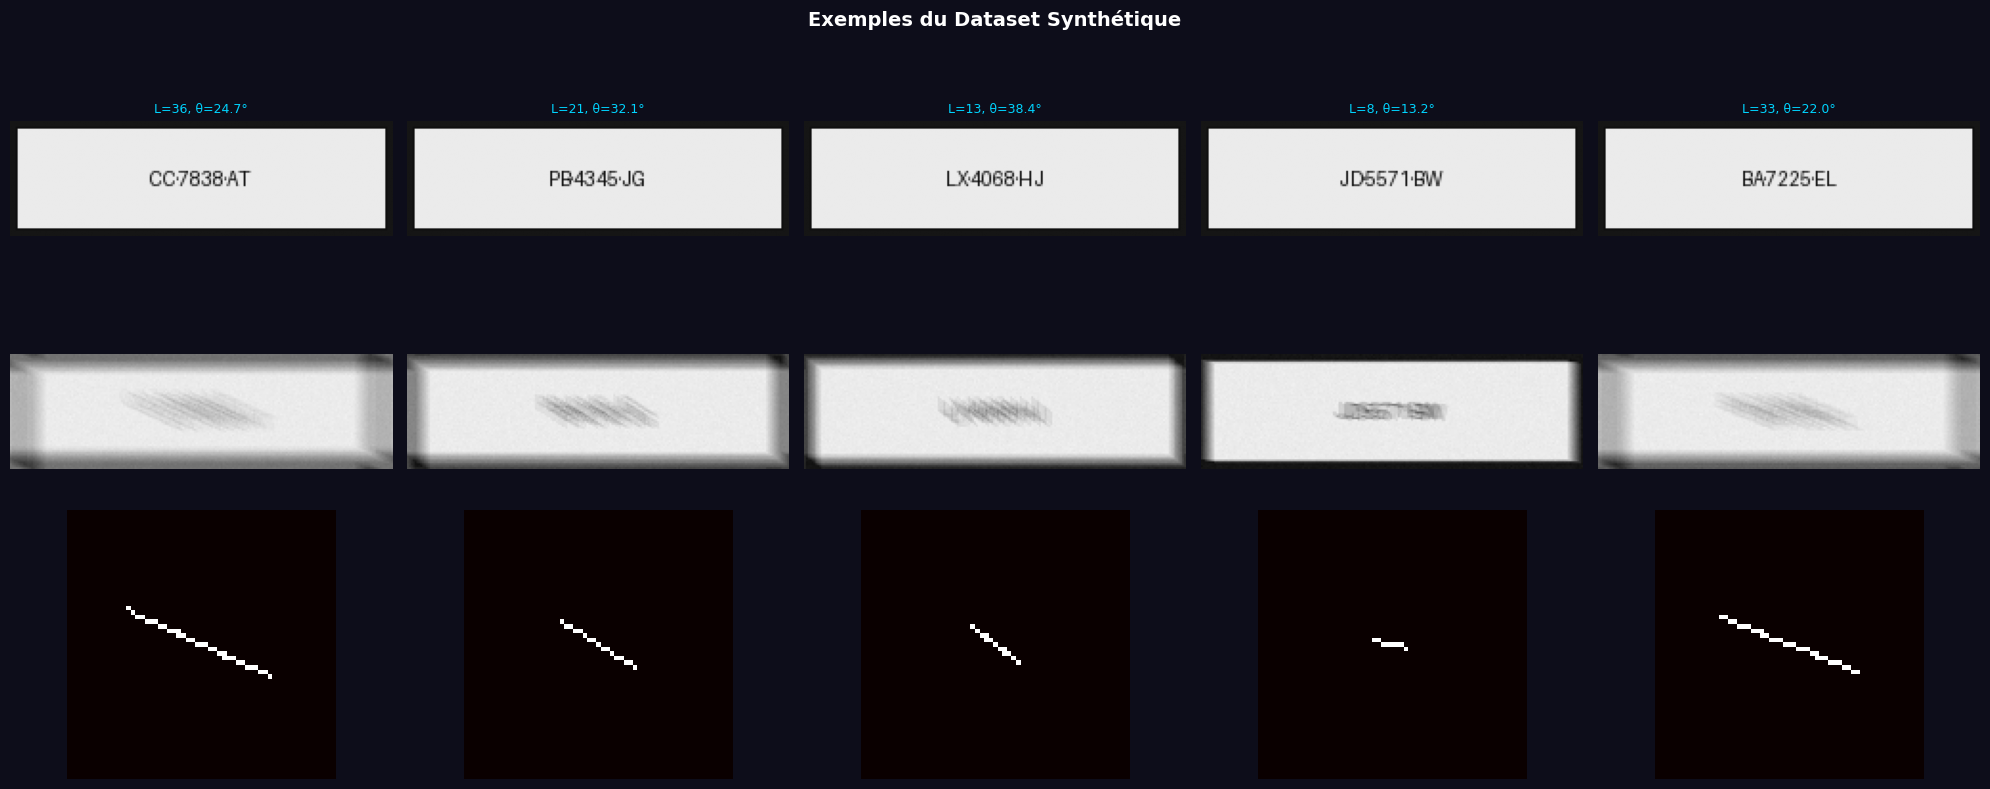

In [3]:
class LicensePlateGenerator:
    """
    Génère des images synthétiques de plaques d'immatriculation.

    Les plaques sont générées avec du texte aléatoire sur fond blanc,
    puis converties en niveaux de gris normalisées [0, 1].
    """

    PLATE_CHARS = 'ABCDEFGHJKLMNPQRSTUVWXYZ0123456789'
    PLATE_WIDTH, PLATE_HEIGHT = 200, 60

    @staticmethod
    def random_plate_text() -> str:
        """Génère un texte de plaque aléatoire (format marocain WW-NNNN-WW)."""
        letters = 'ABCDEFGHJKLMNPQRSTUVWXYZ'
        digits  = '0123456789'
        prefix  = ''.join(random.choices(letters, k=2))
        number  = ''.join(random.choices(digits, k=4))
        suffix  = ''.join(random.choices(letters, k=2))
        return f"{prefix}·{number}·{suffix}"

    @classmethod
    def generate_plate_image(cls) -> np.ndarray:
        """
        Crée une image de plaque synthétique.

        Returns
        -------
        plate : np.ndarray shape (H, W) float32 in [0, 1]
        """
        W, H = cls.PLATE_WIDTH, cls.PLATE_HEIGHT
        img = Image.new('RGB', (W, H), color=(240, 240, 200))  # fond jaunâtre
        draw = ImageDraw.Draw(img)

        # Bordure bleue (style marocain)
        draw.rectangle([0, 0, W-1, H-1], outline=(0, 0, 180), width=3)
        draw.rectangle([3, 3, W-4, H-4], outline=(0, 0, 120), width=1)

        # Texte
        text = cls.random_plate_text()
        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 26)
        except:
            font = ImageFont.load_default()

        # Centrer le texte
        bbox = draw.textbbox((0, 0), text, font=font)
        tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
        draw.text(((W - tw) // 2, (H - th) // 2 - 2), text,
                   fill=(10, 10, 10), font=font)

        # Convertir en gris normalisé
        gray = np.array(img.convert('L')).astype(np.float32) / 255.0
        return gray


class BlurDataset:
    """
    Dataset de paires (image_floue, image_nette) avec paramètres de flou connus.

    Parameters
    ----------
    n_samples   : int   — nombre d'images à générer
    length_range: tuple — (min, max) longueur du flou
    angle_range : tuple — (min, max) angle en degrés
    noise_std   : float — écart-type du bruit gaussien ajouté
    """

    def __init__(self, n_samples=200, length_range=(5, 50),
                 angle_range=(0, 45), noise_std=0.01):
        self.n_samples    = n_samples
        self.length_range = length_range
        self.angle_range  = angle_range
        self.noise_std    = noise_std
        self.samples      = []
        self._generate()

    def _apply_blur(self, image: np.ndarray, psf: np.ndarray) -> np.ndarray:
        """
        Applique le flou par convolution FFT et ajoute du bruit gaussien.

        Parameters
        ----------
        image : np.ndarray (H, W) float32
        psf   : np.ndarray (k, k) float32

        Returns
        -------
        blurred : np.ndarray (H, W) float32 clippée [0, 1]
        """
        # Convolution dans le domaine fréquentiel
        H, W   = image.shape
        psf_pad = np.zeros_like(image)
        ph, pw  = psf.shape
        ch, cw  = ph // 2, pw // 2
        psf_pad[:ph, :pw] = psf
        psf_pad = np.roll(psf_pad, (-ch, -cw), axis=(0, 1))

        F_img = np.fft.fft2(image)
        F_psf = np.fft.fft2(psf_pad)
        blurred = np.real(np.fft.ifft2(F_img * F_psf))

        # Bruit gaussien
        noise   = np.random.normal(0, self.noise_std, blurred.shape).astype(np.float32)
        blurred = np.clip(blurred + noise, 0, 1).astype(np.float32)
        return blurred

    def _generate(self):
        """Génère toutes les paires (sharp, blurred, params)."""
        print(f"⏳ Génération de {self.n_samples} échantillons...")
        for i in range(self.n_samples):
            length = random.randint(*self.length_range)
            angle  = random.uniform(*self.angle_range)
            sharp  = LicensePlateGenerator.generate_plate_image()
            # Ensure PSF size is not larger than the image dimensions
            # Adjust size to be odd and within image bounds, as PSFGenerator might add 1.
            max_psf_dim = min(sharp.shape)
            psf_size = max_psf_dim if max_psf_dim % 2 != 0 else max_psf_dim - 1
            if psf_size < 1: psf_size = 1 # Ensure minimum size if image is very small
            psf    = PSFGenerator.generate(length, angle, size=psf_size)
            blurred = self._apply_blur(sharp, psf)
            self.samples.append({
                'sharp':   sharp,
                'blurred': blurred,
                'psf':     psf,
                'length':  length,
                'angle':   angle
            })
            if (i + 1) % 50 == 0:
                print(f"   {i+1}/{self.n_samples} ✓")
        print(f"✅ Dataset généré : {len(self.samples)} paires")

    def show_samples(self, n=4):
        """Visualise n paires aléatoires du dataset."""
        idxs = random.sample(range(len(self.samples)), n)
        fig, axes = plt.subplots(3, n, figsize=(4 * n, 8), facecolor='#0d0d1a')
        titles = ['Sharp (original)', 'Blurred (input)', 'PSF kernel']
        colors = ['#00d4ff', '#ff6b6b', '#ffd700']

        for j, idx in enumerate(idxs):
            s = self.samples[idx]
            axes[0][j].imshow(s['sharp'],   cmap='gray', vmin=0, vmax=1)
            axes[1][j].imshow(s['blurred'], cmap='gray', vmin=0, vmax=1)
            axes[2][j].imshow(s['psf'],     cmap='hot')
            axes[0][j].set_title(f"L={s['length']}, θ={s['angle']:.1f}°",
                                   color='#00d4ff', fontsize=9)
            for k in range(3):
                axes[k][j].axis('off')

        for k, (title, color) in enumerate(zip(titles, colors)):
            axes[k][0].set_ylabel(title, color=color, fontsize=10, rotation=90,
                                   labelpad=10)
            axes[k][0].yaxis.set_visible(True)

        fig.suptitle('Exemples du Dataset Synthétique', color='white',
                      fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('dataset_samples.png', dpi=120, bbox_inches='tight',
                    facecolor='#0d0d1a')
        plt.show()


# Génération du dataset
dataset = BlurDataset(n_samples=300, length_range=(5, 50),
                       angle_range=(0, 45), noise_std=0.008)
dataset.show_samples(n=5)

---
##  Cellule 3 — Analyse Fréquentielle du Flou

Le flou de mouvement crée des **zéros périodiques** (dark fringes) dans le spectre FFT, perpendiculaires à la direction du flou.

$$|F_{\text{blurred}}(u,v)| = |F_{\text{sharp}}(u,v)| \cdot |H(u,v)|$$

On peut donc estimer $L$ et $\theta$ en analysant le motif de franges du spectre.

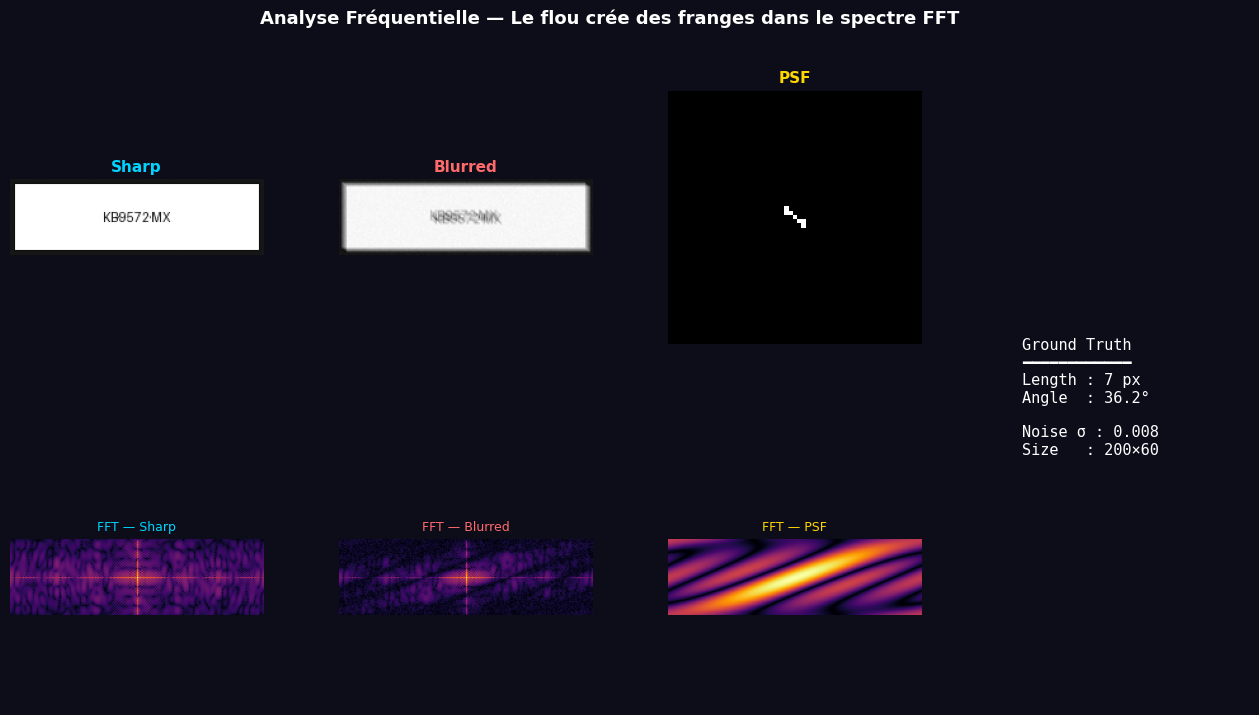


⏳ Test d'estimation FFT (peut prendre ~30s)...

────────────────────────────────────────
  Vérité terrain → L = 7 px, θ = 36.2°
  Estimation FFT → L = 8 px, θ = 35°
  Score corrélation = 0.5679
────────────────────────────────────────


In [4]:
class FrequencyAnalyzer:
    """
    Analyse le spectre FFT d'une image floue pour estimer les paramètres du PSF.

    Méthode : Les franges sombres dans le log-spectre sont perpendiculaires
    à la direction du flou. On détecte leur espacement pour estimer L et θ.
    """

    @staticmethod
    def compute_log_spectrum(image: np.ndarray) -> np.ndarray:
        """
        Calcule le log-spectre de magnitude FFT (centré).

        Parameters
        ----------
        image : np.ndarray (H, W) float32

        Returns
        -------
        log_mag : np.ndarray (H, W) float32
        """
        F  = np.fft.fft2(image)
        Fc = np.fft.fftshift(F)
        mag = np.abs(Fc)
        log_mag = np.log1p(mag).astype(np.float32)
        return log_mag

    @staticmethod
    def estimate_blur_fft(blurred: np.ndarray,
                           length_range=(5, 60),
                           angle_range=(0, 180)) -> dict:
        """
        Estimation des paramètres de flou par corrélation du spectre FFT.

        On génère des PSF candidates, calcule leur spectre et cherche
        la meilleure correspondance avec le spectre de l'image floue.

        Parameters
        ----------
        blurred      : np.ndarray (H, W) float32 — image floue
        length_range : tuple (min_L, max_L)
        angle_range  : tuple (min_θ, max_θ) en degrés

        Returns
        -------
        result : dict avec clés 'length', 'angle', 'score'
        """
        H, W = blurred.shape
        spec_blurred = FrequencyAnalyzer.compute_log_spectrum(blurred)
        # Normalisation
        sb = (spec_blurred - spec_blurred.min()) / (np.ptp(spec_blurred) + 1e-8)

        best = {'length': 20, 'angle': 0, 'score': -np.inf}

        for length in range(length_range[0], length_range[1] + 1, 3):
            for angle in range(angle_range[0], angle_range[1], 5):
                psf  = PSFGenerator.generate(length, angle, size=min(H, W) // 2 + 1)
                # Pad PSF à la taille de l'image
                psf_pad = np.zeros((H, W), dtype=np.float32)
                ph, pw = psf.shape
                psf_pad[:ph, :pw] = psf
                psf_pad = np.roll(psf_pad, (-(ph//2), -(pw//2)), axis=(0,1))

                spec_psf = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(psf_pad))))
                sp = (spec_psf - spec_psf.min()) / (np.ptp(spec_psf) + 1e-8)

                # Corrélation normalisée
                score = float(np.corrcoef(sb.ravel(), sp.ravel())[0, 1])
                if score > best['score']:
                    best = {'length': length, 'angle': angle, 'score': score}

        return best

    @staticmethod
    def visualize_fft_analysis(sample: dict):
        """Affiche l'analyse FFT d'un échantillon avec vérité terrain vs estimation."""
        sharp   = sample['sharp']
        blurred = sample['blurred']
        psf_true = sample['psf']

        spec_sharp   = FrequencyAnalyzer.compute_log_spectrum(sharp)
        spec_blurred = FrequencyAnalyzer.compute_log_spectrum(blurred)
        spec_psf     = FrequencyAnalyzer.compute_log_spectrum(
            np.pad(psf_true, ((0, sharp.shape[0]-psf_true.shape[0]),
                               (0, sharp.shape[1]-psf_true.shape[1])))
        )

        fig = plt.figure(figsize=(16, 8), facecolor='#0d0d1a')
        gs  = gridspec.GridSpec(2, 4, figure=fig,
                                 hspace=0.4, wspace=0.3)

        data = [
            (sharp,        spec_sharp,   'Sharp',   '#00d4ff'),
            (blurred,      spec_blurred, 'Blurred', '#ff6b6b'),
            (psf_true,     spec_psf,     'PSF',     '#ffd700'),
        ]

        for col, (img, spec, label, c) in enumerate(data):
            ax_img  = fig.add_subplot(gs[0, col])
            ax_spec = fig.add_subplot(gs[1, col])
            ax_img.imshow(img,  cmap='gray', vmin=0, vmax=img.max())
            ax_img.set_title(label, color=c, fontsize=11, fontweight='bold')
            ax_img.axis('off')
            ax_spec.imshow(spec, cmap='inferno')
            ax_spec.set_title(f'FFT — {label}', color=c, fontsize=9)
            ax_spec.axis('off')

        # Panneau d'info
        ax_info = fig.add_subplot(gs[:, 3])
        ax_info.set_facecolor('#111122')
        ax_info.axis('off')
        info = (
            f"Ground Truth\n"
            f"━━━━━━━━━━━━\n"
            f"Length : {sample['length']} px\n"
            f"Angle  : {sample['angle']:.1f}°\n\n"
            f"Noise σ : 0.008\n"
            f"Size   : {sharp.shape[1]}×{sharp.shape[0]}"
        )
        ax_info.text(0.1, 0.5, info, transform=ax_info.transAxes,
                      fontsize=11, color='white', fontfamily='monospace',
                      verticalalignment='center')

        fig.suptitle('Analyse Fréquentielle — Le flou crée des franges dans le spectre FFT',
                      color='white', fontsize=13, fontweight='bold')
        plt.savefig('fft_analysis.png', dpi=120, bbox_inches='tight', facecolor='#0d0d1a')
        plt.show()


# Démonstration sur un échantillon
sample_demo = dataset.samples[7]
FrequencyAnalyzer.visualize_fft_analysis(sample_demo)

print("\n⏳ Test d'estimation FFT (peut prendre ~30s)...")
estimated = FrequencyAnalyzer.estimate_blur_fft(sample_demo['blurred'])
print(f"\n{'─'*40}")
print(f"  Vérité terrain → L = {sample_demo['length']} px, θ = {sample_demo['angle']:.1f}°")
print(f"  Estimation FFT → L = {estimated['length']} px, θ = {estimated['angle']}°")
print(f"  Score corrélation = {estimated['score']:.4f}")
print(f"{'─'*40}")

---
##  Cellule 4 — [BONUS] CNN Estimator du PSF

Un réseau léger prend en entrée le **log-spectre FFT** de l'image floue et prédit directement $(L, \theta)$.

Architecture : `ConvBlock × 4 → GlobalAvgPool → FC → (L, θ)`

🧠 Entraînement CNN sur cuda — 60 epochs
   421,474 paramètres
  Epoch   1/60 | Train Loss: 0.06458 | Val Loss: 0.06300
  Epoch  10/60 | Train Loss: 0.00746 | Val Loss: 0.00505
  Epoch  20/60 | Train Loss: 0.00505 | Val Loss: 0.00149
  Epoch  30/60 | Train Loss: 0.00363 | Val Loss: 0.00168
  Epoch  40/60 | Train Loss: 0.00412 | Val Loss: 0.00138
  Epoch  50/60 | Train Loss: 0.00254 | Val Loss: 0.00144
  Epoch  60/60 | Train Loss: 0.00334 | Val Loss: 0.00150


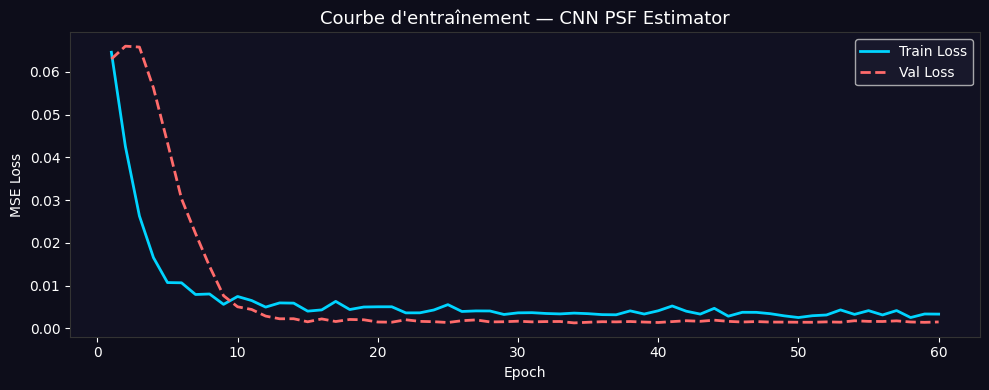


📊 Évaluation CNN sur 30 échantillons :
   Erreur moyenne Length : 1.90 px  (std=1.37)
   Erreur moyenne Angle  : 1.30°    (std=0.83)
💾 Modèle sauvegardé → psf_cnn.pth


In [5]:
class PSFEstimatorCNN(nn.Module):
    """
    CNN léger pour estimer les paramètres de flou (length, angle) depuis le spectre FFT.

    Input  : Tensor (B, 1, H, W) — log-spectre normalisé de l'image floue
    Output : Tensor (B, 2)       — [length_norm, angle_norm] ∈ [0, 1]

    Les valeurs normalisées sont remappées à leurs plages réelles à l'inférence.
    """

    def __init__(self):
        super().__init__()
        def conv_block(in_ch, out_ch, stride=2):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.GELU(),
                nn.Dropout2d(0.1)
            )
        self.encoder = nn.Sequential(
            conv_block(1,  32),   # H/2
            conv_block(32, 64),   # H/4
            conv_block(64, 128),  # H/8
            conv_block(128, 256), # H/16
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2),
            nn.Sigmoid()  # Output in [0, 1]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : Tensor (B, 1, H, W)

        Returns
        -------
        out : Tensor (B, 2) — [length_norm, angle_norm]
        """
        return self.head(self.gap(self.encoder(x)))


class PSFDatasetTorch(Dataset):
    """
    Dataset PyTorch pour l'entraînement du CNN estimateur de PSF.

    Parameters
    ----------
    samples       : list de dict avec clés 'blurred', 'length', 'angle'
    length_max    : float — valeur max de L pour normalisation
    angle_max     : float — valeur max de θ pour normalisation
    img_size      : int   — taille de resize pour homogénéité
    """

    def __init__(self, samples, length_max=50.0, angle_max=45.0, img_size=64):
        self.samples    = samples
        self.length_max = length_max
        self.angle_max  = angle_max
        self.img_size   = img_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        """
        Returns
        -------
        fft_tensor : Tensor (1, img_size, img_size)
        label      : Tensor (2,) — [length_norm, angle_norm]
        """
        s       = self.samples[idx]
        blurred = s['blurred']

        # Log-spectre FFT
        spec = FrequencyAnalyzer.compute_log_spectrum(blurred)
        spec_resized = cv2.resize(spec, (self.img_size, self.img_size))
        # Normalisation min-max
        mn, mx = spec_resized.min(), spec_resized.max()
        spec_norm = (spec_resized - mn) / (mx - mn + 1e-8)

        fft_tensor = torch.tensor(spec_norm, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor([
            s['length'] / self.length_max,
            s['angle']  / self.angle_max
        ], dtype=torch.float32)
        return fft_tensor, label


class PSFTrainer:
    """
    Entraîne et évalue le CNN estimateur de PSF.
    """

    def __init__(self, dataset_samples, split=0.8,
                 length_max=50.0, angle_max=45.0):
        n_train = int(len(dataset_samples) * split)
        train_s = dataset_samples[:n_train]
        val_s   = dataset_samples[n_train:]

        self.length_max = length_max
        self.angle_max  = angle_max

        train_ds = PSFDatasetTorch(train_s, length_max, angle_max)
        val_ds   = PSFDatasetTorch(val_s,   length_max, angle_max)

        self.train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        self.val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

        self.model = PSFEstimatorCNN().to(DEVICE)
        self.optimizer = optim.AdamW(self.model.parameters(), lr=3e-4,
                                      weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=50)
        self.criterion = nn.MSELoss()
        self.history   = {'train_loss': [], 'val_loss': []}

    def _epoch(self, loader, train=True):
        self.model.train(train)
        total_loss = 0.0
        with torch.set_grad_enabled(train):
            for x, y in loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                pred = self.model(x)
                loss = self.criterion(pred, y)
                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()
                total_loss += loss.item() * x.size(0)
        return total_loss / len(loader.dataset)

    def train(self, epochs=50):
        """Boucle d'entraînement complète avec affichage de la courbe de loss."""
        print(f"🧠 Entraînement CNN sur {DEVICE} — {epochs} epochs")
        print(f"   {sum(p.numel() for p in self.model.parameters()):,} paramètres")
        for ep in range(1, epochs + 1):
            tl = self._epoch(self.train_loader, train=True)
            vl = self._epoch(self.val_loader,   train=False)
            self.scheduler.step()
            self.history['train_loss'].append(tl)
            self.history['val_loss'].append(vl)
            if ep % 10 == 0 or ep == 1:
                print(f"  Epoch {ep:3d}/{epochs} | Train Loss: {tl:.5f} | Val Loss: {vl:.5f}")
        self._plot_training()
        return self.model

    def _plot_training(self):
        """Affiche les courbes de loss train/val."""
        fig, ax = plt.subplots(figsize=(10, 4), facecolor='#0d0d1a')
        ax.set_facecolor('#111122')
        epochs_range = range(1, len(self.history['train_loss']) + 1)
        ax.plot(epochs_range, self.history['train_loss'], color='#00d4ff',
                 label='Train Loss', linewidth=2)
        ax.plot(epochs_range, self.history['val_loss'],   color='#ff6b6b',
                 label='Val Loss',   linewidth=2, linestyle='--')
        ax.set_xlabel('Epoch', color='white')
        ax.set_ylabel('MSE Loss', color='white')
        ax.set_title('Courbe d\'entraînement — CNN PSF Estimator',
                      color='white', fontsize=13)
        ax.tick_params(colors='white')
        ax.legend(facecolor='#1a1a2e', labelcolor='white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#333')
        plt.tight_layout()
        plt.savefig('cnn_training.png', dpi=120, bbox_inches='tight', facecolor='#0d0d1a')
        plt.show()

    @torch.no_grad()
    def predict(self, blurred: np.ndarray) -> dict:
        """
        Prédit (length, angle) depuis une image floue.

        Parameters
        ----------
        blurred : np.ndarray (H, W) float32

        Returns
        -------
        dict avec clés 'length' (int) et 'angle' (float)
        """
        self.model.eval()
        spec = FrequencyAnalyzer.compute_log_spectrum(blurred)
        spec_r = cv2.resize(spec, (64, 64))
        mn, mx = spec_r.min(), spec_r.max()
        spec_n = (spec_r - mn) / (mx - mn + 1e-8)
        x = torch.tensor(spec_n, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
        pred = self.model(x).squeeze().cpu().numpy()
        return {
            'length': int(round(float(pred[0]) * self.length_max)),
            'angle':  float(pred[1]) * self.angle_max
        }

    def evaluate_on_dataset(self, n=30):
        """Affiche les erreurs d'estimation sur n échantillons de validation."""
        errors_L, errors_A = [], []
        val_samples = dataset.samples[int(len(dataset.samples)*0.8):]
        for s in val_samples[:n]:
            pred = self.predict(s['blurred'])
            errors_L.append(abs(pred['length'] - s['length']))
            errors_A.append(abs(pred['angle']  - s['angle']))

        print(f"\n📊 Évaluation CNN sur {n} échantillons :")
        print(f"   Erreur moyenne Length : {np.mean(errors_L):.2f} px  (std={np.std(errors_L):.2f})")
        print(f"   Erreur moyenne Angle  : {np.mean(errors_A):.2f}°    (std={np.std(errors_A):.2f})")


# Entraînement
trainer = PSFTrainer(dataset.samples)
cnn_model = trainer.train(epochs=60)
trainer.evaluate_on_dataset(n=30)
torch.save(cnn_model.state_dict(), 'psf_cnn.pth')
print("💾 Modèle sauvegardé → psf_cnn.pth")

---
## 🔧 Cellule 5 — Méthodes de Déconvolution

On implémente et compare **3 méthodes** :

| Méthode | Formule | Robustesse au bruit |
|---------|---------|---------------------|
| Inverse naïve | $\hat{F} = G / H$ | ❌ Nulle |
| Filtre de Wiener | $\hat{F} = \frac{H^*}{|H|^2 + K} \cdot G$ | ✅ Bonne |
| Tikhonov (régularisé) | $\hat{F} = \frac{H^*}{|H|^2 + \lambda |L|^2} \cdot G$ | ✅✅ Excellente |

In [6]:
class DeconvolutionEngine:
    """
    Moteur de déconvolution implémentant 3 méthodes dans le domaine fréquentiel.

    Toutes les méthodes opèrent selon :
    1. FFT de l'image floue et du PSF
    2. Filtre dans le domaine fréquentiel
    3. IFFT → image restaurée
    """

    @staticmethod
    def _prepare_fft(blurred: np.ndarray,
                      psf: np.ndarray) -> tuple:
        """
        Prépare les FFTs de l'image floue et du PSF.

        Parameters
        ----------
        blurred : np.ndarray (H, W) float32
        psf     : np.ndarray (k, k) float32

        Returns
        -------
        G    : np.ndarray complexe — FFT de l'image floue
        H    : np.ndarray complexe — FFT du PSF paddé
        H_conj : conjugué de H
        H_sq   : |H|²
        """
        H_img, W_img = blurred.shape

        # Padding du PSF à la taille de l'image (centré à l'origine)
        psf_pad = np.zeros((H_img, W_img), dtype=np.float32)
        ph, pw  = psf.shape
        psf_pad[:ph, :pw] = psf
        psf_pad = np.roll(psf_pad, (-(ph // 2), -(pw // 2)), axis=(0, 1))

        G      = np.fft.fft2(blurred.astype(np.float64))
        H      = np.fft.fft2(psf_pad.astype(np.float64))
        H_conj = np.conj(H)
        H_sq   = np.abs(H) ** 2
        return G, H, H_conj, H_sq

    @classmethod
    def naive_inverse(cls, blurred: np.ndarray, psf: np.ndarray,
                       epsilon: float = 1e-3) -> np.ndarray:
        """
        Filtre inverse naïf : F̂ = G / H (avec seuillage pour éviter la division par zéro).

        Très sensible au bruit — résultat de référence uniquement.

        Parameters
        ----------
        blurred : np.ndarray (H, W)
        psf     : np.ndarray (k, k)
        epsilon : float — seuil pour éviter division par zéro

        Returns
        -------
        restored : np.ndarray (H, W) float32 clippée [0, 1]
        """
        G, H, _, _ = cls._prepare_fft(blurred, psf)
        H_safe = np.where(np.abs(H) < epsilon, epsilon, H)
        F_hat  = G / H_safe
        restored = np.real(np.fft.ifft2(F_hat)).astype(np.float32)
        return np.clip(restored, 0, 1)

    @classmethod
    def wiener_filter(cls, blurred: np.ndarray, psf: np.ndarray,
                       K: float = 0.01) -> np.ndarray:
        """
        Filtre de Wiener classique.

        F̂ = [H* / (|H|² + K)] · G

        K est le rapport signal-sur-bruit inverse (NSR = σ²_n / σ²_f).
        Un K plus grand → plus de lissage, moins de ringing.

        Parameters
        ----------
        blurred : np.ndarray (H, W)
        psf     : np.ndarray (k, k)
        K       : float — paramètre de régularisation (NSR)

        Returns
        -------
        restored : np.ndarray (H, W) float32 clippée [0, 1]
        """
        G, _, H_conj, H_sq = cls._prepare_fft(blurred, psf)
        W     = H_conj / (H_sq + K)
        F_hat = W * G
        restored = np.real(np.fft.ifft2(F_hat)).astype(np.float32)
        return np.clip(restored, 0, 1)

    @classmethod
    def tikhonov_filter(cls, blurred: np.ndarray, psf: np.ndarray,
                         lam: float = 0.05) -> np.ndarray:
        """
        Filtre de Tikhonov (Wiener régularisé avec prior de Laplacien).

        F̂ = [H* / (|H|² + λ|L|²)] · G

        où L est le laplacien (opérateur de régularisation favorisant le lissage).
        Plus robuste que Wiener simple grâce au prior spatial sur la solution.

        Parameters
        ----------
        blurred : np.ndarray (H, W)
        psf     : np.ndarray (k, k)
        lam     : float — paramètre de régularisation λ

        Returns
        -------
        restored : np.ndarray (H, W) float32 clippée [0, 1]
        """
        H_img, W_img = blurred.shape
        G, _, H_conj, H_sq = cls._prepare_fft(blurred, psf)

        # Noyau Laplacien dans le domaine fréquentiel
        laplacian       = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype=np.float64)
        lap_pad         = np.zeros((H_img, W_img), dtype=np.float64)
        lap_pad[:3, :3] = laplacian
        lap_pad         = np.roll(lap_pad, (-1, -1), axis=(0, 1))
        L_sq            = np.abs(np.fft.fft2(lap_pad)) ** 2

        W     = H_conj / (H_sq + lam * L_sq)
        F_hat = W * G
        restored = np.real(np.fft.ifft2(F_hat)).astype(np.float32)
        return np.clip(restored, 0, 1)

print("✅ DeconvolutionEngine chargé avec 3 méthodes :")
print("   • naive_inverse    (référence)")
print("   • wiener_filter    (classique)")
print("   • tikhonov_filter  (régularisé — meilleure qualité)")

✅ DeconvolutionEngine chargé avec 3 méthodes :
   • naive_inverse    (référence)
   • wiener_filter    (classique)
   • tikhonov_filter  (régularisé — meilleure qualité)


---
## 📊 Cellule 6 — Métriques de Qualité : PSNR & SSIM

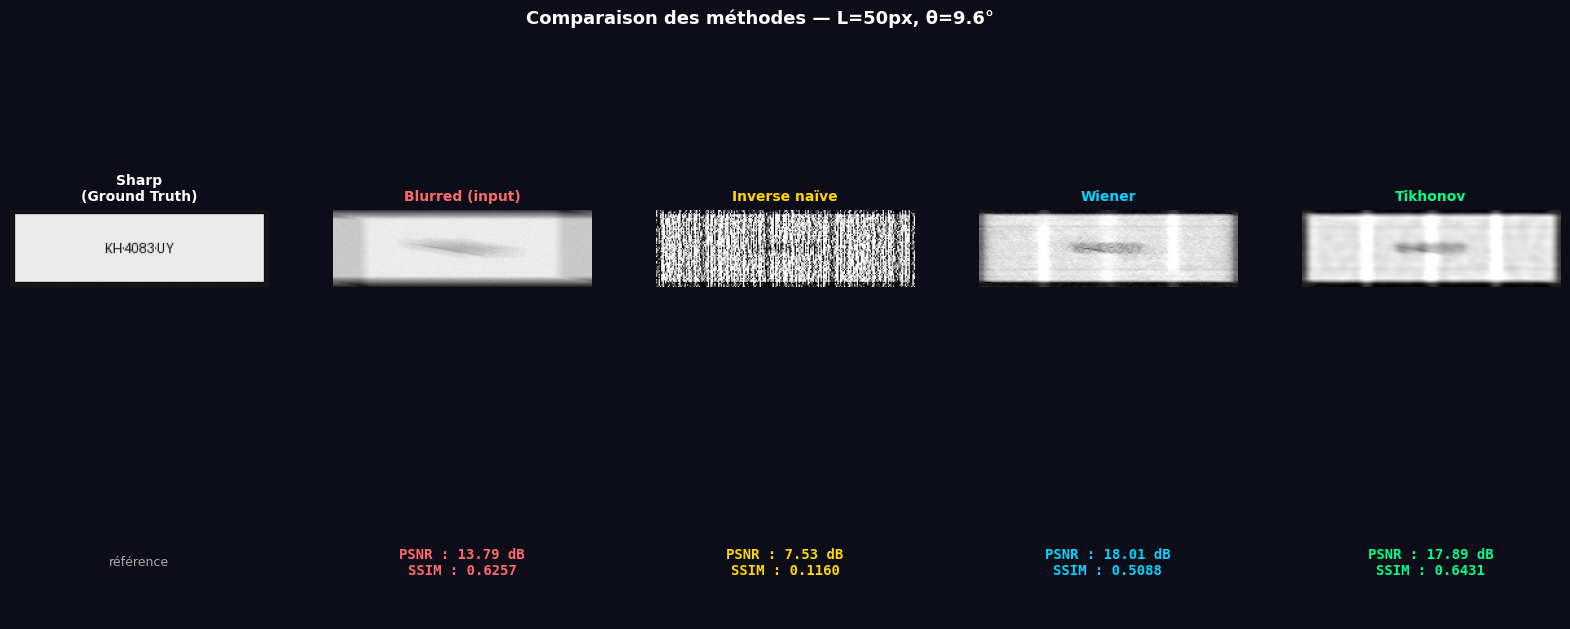

In [7]:
class QualityEvaluator:
    """
    Calcule les métriques de qualité d'image pour comparer les méthodes.

    Métriques implémentées :
    - PSNR (Peak Signal-to-Noise Ratio) en dB — plus élevé = mieux
    - SSIM (Structural Similarity Index)  ∈ [0,1] — plus proche de 1 = mieux
    """

    @staticmethod
    def psnr(reference: np.ndarray, restored: np.ndarray) -> float:
        """
        Peak Signal-to-Noise Ratio.

        PSNR = 10 · log₁₀(MAX² / MSE)

        Parameters
        ----------
        reference : np.ndarray (H, W) float32 — image originale
        restored  : np.ndarray (H, W) float32 — image restaurée

        Returns
        -------
        psnr_db : float — PSNR en décibels
        """
        return float(metrics.peak_signal_noise_ratio(
            reference, restored, data_range=1.0))

    @staticmethod
    def ssim(reference: np.ndarray, restored: np.ndarray) -> float:
        """
        Structural Similarity Index Measure.

        Parameters
        ----------
        reference : np.ndarray (H, W) float32
        restored  : np.ndarray (H, W) float32

        Returns
        -------
        ssim_val : float ∈ [0, 1]
        """
        return float(metrics.structural_similarity(
            reference, restored, data_range=1.0))

    @classmethod
    def full_comparison(cls, sample: dict,
                         K: float = 0.01,
                         lam: float = 0.05) -> dict:
        """
        Compare toutes les méthodes sur un échantillon.

        Parameters
        ----------
        sample : dict avec 'sharp', 'blurred', 'psf'
        K      : float — paramètre Wiener
        lam    : float — paramètre Tikhonov

        Returns
        -------
        results : dict {method_name: {'image': ..., 'psnr': ..., 'ssim': ...}}
        """
        sharp   = sample['sharp']
        blurred = sample['blurred']
        psf     = sample['psf']

        eng = DeconvolutionEngine
        results = {
            'Blurred (input)': {
                'image': blurred,
                'psnr':  cls.psnr(sharp, blurred),
                'ssim':  cls.ssim(sharp, blurred)
            },
            'Inverse naïve': {
                'image': eng.naive_inverse(blurred, psf),
                'psnr':  None, 'ssim': None
            },
            'Wiener': {
                'image': eng.wiener_filter(blurred, psf, K=K),
                'psnr':  None, 'ssim': None
            },
            'Tikhonov': {
                'image': eng.tikhonov_filter(blurred, psf, lam=lam),
                'psnr':  None, 'ssim': None
            }
        }

        for name in ['Inverse naïve', 'Wiener', 'Tikhonov']:
            img = results[name]['image']
            results[name]['psnr'] = cls.psnr(sharp, img)
            results[name]['ssim'] = cls.ssim(sharp, img)

        return results

    @classmethod
    def plot_comparison(cls, sample: dict, K=0.01, lam=0.05):
        """Affiche la comparaison visuelle + métriques de toutes les méthodes."""
        results = cls.full_comparison(sample, K=K, lam=lam)
        methods = list(results.keys())
        n = len(methods) + 1  # +1 pour sharp

        fig = plt.figure(figsize=(4 * n, 7), facecolor='#0d0d1a')
        gs  = gridspec.GridSpec(2, n, figure=fig,
                                 height_ratios=[3, 1], hspace=0.4, wspace=0.25)

        color_map = {
            'Blurred (input)': '#ff6b6b',
            'Inverse naïve':   '#ffd700',
            'Wiener':          '#00d4ff',
            'Tikhonov':        '#00ff88'
        }

        # Sharp
        ax = fig.add_subplot(gs[0, 0])
        ax.imshow(sample['sharp'], cmap='gray', vmin=0, vmax=1)
        ax.set_title('Sharp\n(Ground Truth)', color='white',
                      fontsize=10, fontweight='bold')
        ax.axis('off')
        ax_m = fig.add_subplot(gs[1, 0])
        ax_m.text(0.5, 0.5, 'référence', ha='center', va='center',
                   color='#aaa', fontsize=9, transform=ax_m.transAxes)
        ax_m.axis('off')

        for col, (name, res) in enumerate(results.items(), start=1):
            c   = color_map[name]
            ax  = fig.add_subplot(gs[0, col])
            ax.imshow(res['image'], cmap='gray', vmin=0, vmax=1)
            ax.set_title(name, color=c, fontsize=10, fontweight='bold')
            ax.axis('off')

            ax_m = fig.add_subplot(gs[1, col])
            ax_m.set_facecolor('#111122')
            ax_m.axis('off')
            if res['psnr'] is not None:
                metric_text = (
                    f"PSNR : {res['psnr']:.2f} dB\n"
                    f"SSIM : {res['ssim']:.4f}"
                )
                ax_m.text(0.5, 0.5, metric_text, ha='center', va='center',
                           color=c, fontsize=10, fontfamily='monospace',
                           fontweight='bold', transform=ax_m.transAxes)

        fig.suptitle(
            f"Comparaison des méthodes — L={sample['length']}px, θ={sample['angle']:.1f}°",
            color='white', fontsize=13, fontweight='bold'
        )
        plt.savefig('deconv_comparison.png', dpi=130, bbox_inches='tight',
                    facecolor='#0d0d1a')
        plt.show()
        return results


# Test sur un échantillon avec fort flou
heavy_blur = max(dataset.samples, key=lambda s: s['length'])
results = QualityEvaluator.plot_comparison(heavy_blur, K=0.01, lam=0.05)

---
## 📈 Cellule 7 — Évaluation Quantitative sur le Dataset Complet

⏳ Benchmark sur 80 images...
   20/80 ✓
   40/80 ✓
   60/80 ✓
   80/80 ✓


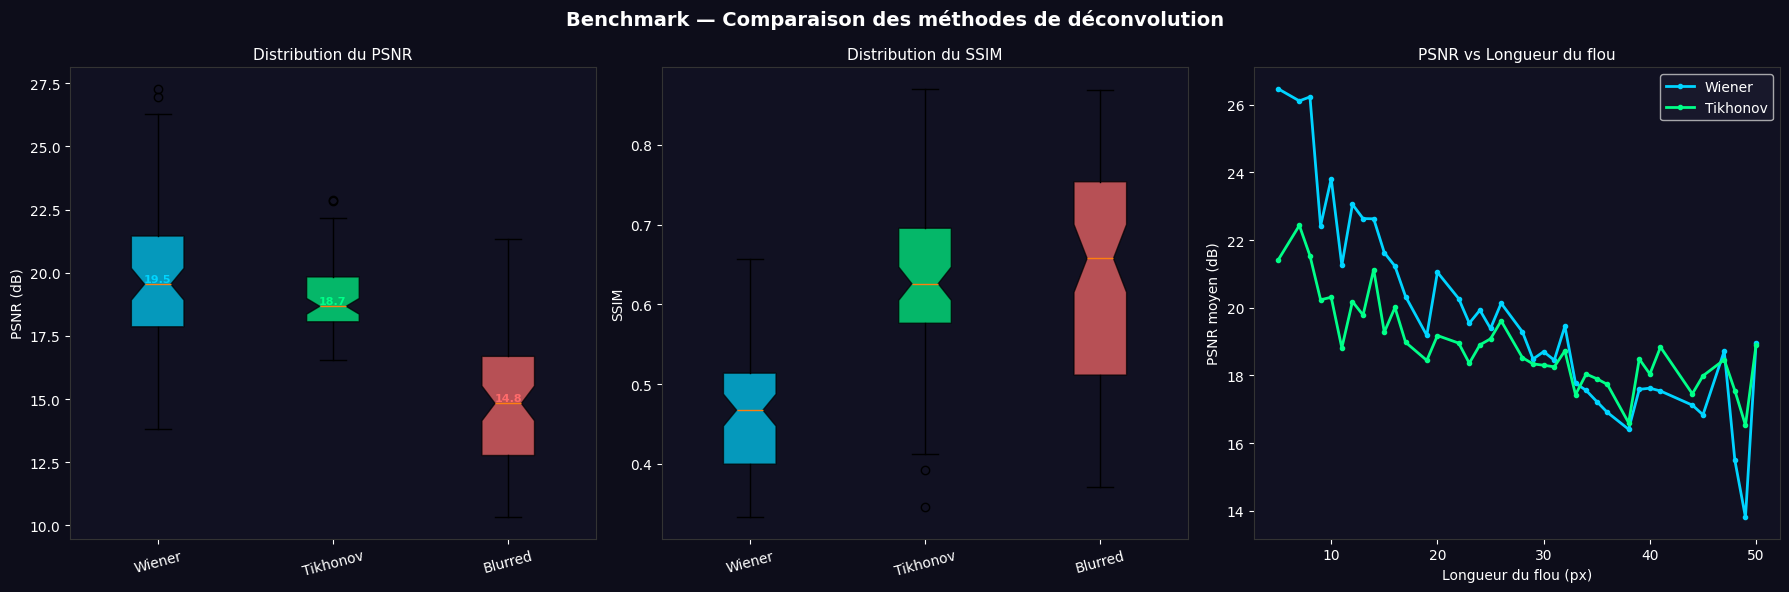


Méthode              PSNR moyen   PSNR max   SSIM moyen
───────────────────────────────────────────────────────
Wiener                  19.97 dB    27.28 dB     0.4689
Tikhonov                19.07 dB    22.89 dB     0.6340
Blurred                 15.01 dB    21.32 dB     0.6335


In [8]:
class BenchmarkEvaluator:
    """
    Évalue les 3 méthodes de déconvolution sur un sous-ensemble du dataset.
    Génère des graphiques de performance et une analyse statistique complète.
    """

    @staticmethod
    def run(samples, n_eval=80, K=0.01, lam=0.05):
        """
        Lance le benchmark complet.

        Parameters
        ----------
        samples : list — échantillons du dataset
        n_eval  : int   — nombre d'images à évaluer
        K       : float — paramètre Wiener
        lam     : float — paramètre Tikhonov

        Returns
        -------
        df_results : dict de listes avec les résultats par méthode
        """
        methods = {
            'Wiener':   lambda b, p: DeconvolutionEngine.wiener_filter(b, p, K=K),
            'Tikhonov': lambda b, p: DeconvolutionEngine.tikhonov_filter(b, p, lam=lam),
        }
        scores = {m: {'psnr': [], 'ssim': [], 'lengths': []} for m in methods}
        scores['Blurred'] = {'psnr': [], 'ssim': [], 'lengths': []}

        eval_samples = random.sample(samples, min(n_eval, len(samples)))
        print(f"⏳ Benchmark sur {len(eval_samples)} images...")

        for i, s in enumerate(eval_samples):
            sharp, blurred, psf = s['sharp'], s['blurred'], s['psf']
            L = s['length']

            scores['Blurred']['psnr'].append(QualityEvaluator.psnr(sharp, blurred))
            scores['Blurred']['ssim'].append(QualityEvaluator.ssim(sharp, blurred))
            scores['Blurred']['lengths'].append(L)

            for name, fn in methods.items():
                restored = fn(blurred, psf)
                scores[name]['psnr'].append(QualityEvaluator.psnr(sharp, restored))
                scores[name]['ssim'].append(QualityEvaluator.ssim(sharp, restored))
                scores[name]['lengths'].append(L)

            if (i+1) % 20 == 0:
                print(f"   {i+1}/{len(eval_samples)} ✓")

        BenchmarkEvaluator._plot_results(scores)
        return scores

    @staticmethod
    def _plot_results(scores):
        """Affiche les graphiques de performance : boxplots + PSNR vs longueur du flou."""
        colors = {'Blurred': '#ff6b6b', 'Wiener': '#00d4ff', 'Tikhonov': '#00ff88'}
        methods = list(scores.keys())

        fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0d0d1a')
        fig.suptitle('Benchmark — Comparaison des méthodes de déconvolution',
                      color='white', fontsize=14, fontweight='bold')

        # --- Boxplot PSNR ---
        ax = axes[0]
        ax.set_facecolor('#111122')
        psnr_data  = [scores[m]['psnr'] for m in methods]
        bp = ax.boxplot(psnr_data, patch_artist=True, notch=True)
        for patch, m in zip(bp['boxes'], methods):
            patch.set_facecolor(colors[m])
            patch.set_alpha(0.7)
        ax.set_xticks(range(1, len(methods)+1))
        ax.set_xticklabels(methods, color='white', rotation=15)
        ax.set_ylabel('PSNR (dB)', color='white')
        ax.set_title('Distribution du PSNR', color='white', fontsize=11)
        ax.tick_params(colors='white')
        for spine in ax.spines.values(): spine.set_edgecolor('#333')
        for m, vals in zip(methods, psnr_data):
            ax.text(methods.index(m)+1, np.median(vals),
                     f'{np.median(vals):.1f}', ha='center', va='bottom',
                     color=colors[m], fontsize=8, fontweight='bold')

        # --- Boxplot SSIM ---
        ax = axes[1]
        ax.set_facecolor('#111122')
        ssim_data = [scores[m]['ssim'] for m in methods]
        bp = ax.boxplot(ssim_data, patch_artist=True, notch=True)
        for patch, m in zip(bp['boxes'], methods):
            patch.set_facecolor(colors[m])
            patch.set_alpha(0.7)
        ax.set_xticks(range(1, len(methods)+1))
        ax.set_xticklabels(methods, color='white', rotation=15)
        ax.set_ylabel('SSIM', color='white')
        ax.set_title('Distribution du SSIM', color='white', fontsize=11)
        ax.tick_params(colors='white')
        for spine in ax.spines.values(): spine.set_edgecolor('#333')

        # --- PSNR vs Longueur du flou ---
        ax = axes[2]
        ax.set_facecolor('#111122')
        for m in ['Wiener', 'Tikhonov']:
            lengths = scores[m]['lengths']
            psnrs   = scores[m]['psnr']
            # Tri et moyennage par longueur
            lens_unique = sorted(set(lengths))
            psnr_mean   = [np.mean([p for p, l in zip(psnrs, lengths) if l == lu])
                            for lu in lens_unique]
            ax.plot(lens_unique, psnr_mean, color=colors[m], label=m,
                     linewidth=2, marker='o', markersize=3)
        ax.set_xlabel('Longueur du flou (px)', color='white')
        ax.set_ylabel('PSNR moyen (dB)', color='white')
        ax.set_title('PSNR vs Longueur du flou', color='white', fontsize=11)
        ax.tick_params(colors='white')
        ax.legend(facecolor='#1a1a2e', labelcolor='white')
        for spine in ax.spines.values(): spine.set_edgecolor('#333')

        plt.tight_layout()
        plt.savefig('benchmark_results.png', dpi=130, bbox_inches='tight',
                    facecolor='#0d0d1a')
        plt.show()

        # Tableau récapitulatif
        print(f"\n{'='*55}")
        print(f"{'Méthode':<18} {'PSNR moyen':>12} {'PSNR max':>10} {'SSIM moyen':>12}")
        print(f"{'─'*55}")
        for m in methods:
            print(f"{m:<18} {np.mean(scores[m]['psnr']):>10.2f} dB "
                   f"{np.max(scores[m]['psnr']):>8.2f} dB "
                   f"{np.mean(scores[m]['ssim']):>10.4f}")
        print(f"{'='*55}")


benchmark_scores = BenchmarkEvaluator.run(dataset.samples, n_eval=80)

---
## 🏆 Cellule 8 — Pipeline Complet & Récapitulatif Final


════════════════════════════════════════════════════════════
  PIPELINE COMPLET — Échantillon : L=27, θ=27.2°
════════════════════════════════════════════════════════════

[1] Estimation du PSF par CNN...
    CNN  → L̂=27px, θ̂=26.1°
    GT   → L =27px,  θ =27.2°
    ΔL=0px, Δθ=1.0°

[2] Déconvolution (3 méthodes × 2 PSF)...

[3] Métriques :
    Méthode                    PSNR       SSIM
    ──────────────────────────────────────────
    Blurred (input)          13.48dB     0.5446
    Wiener-GT                18.73dB     0.4132
    Tikhonov-GT              18.65dB     0.5346
    Wiener-CNN               17.84dB     0.3834
    Tikhonov-CNN             18.39dB     0.5270

💾 Sauvegardé → pipeline_final.png


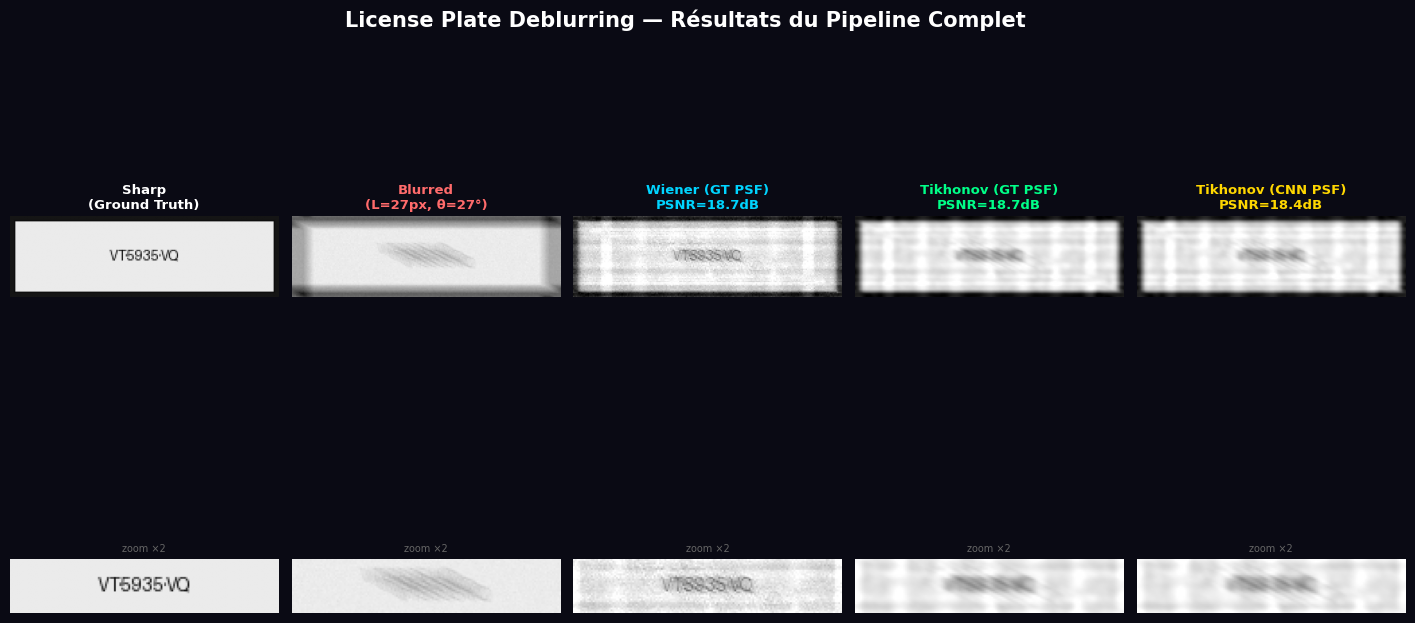


════════════════════════════════════════════════════════════


In [9]:
def run_full_pipeline(sample_idx=None, K=0.01, lam=0.04, save=True):
    """
    Exécute le pipeline complet de défloutage sur un échantillon.

    Pipeline :
    1. Sélection de l'image floue
    2. Estimation du PSF par CNN + FFT
    3. Déconvolution par 3 méthodes
    4. Calcul PSNR / SSIM
    5. Sauvegarde de la figure

    Parameters
    ----------
    sample_idx : int or None — index de l'échantillon (None = meilleur cas)
    K          : float — paramètre Wiener
    lam        : float — paramètre Tikhonov
    save       : bool  — sauvegarder le résultat
    """
    if sample_idx is None:
        # Choisir un échantillon de flou modéré pour bonne démonstration
        sample = [s for s in dataset.samples if 20 <= s['length'] <= 35][0]
    else:
        sample = dataset.samples[sample_idx]

    print(f"\n{'═'*60}")
    print(f"  PIPELINE COMPLET — Échantillon : L={sample['length']}, θ={sample['angle']:.1f}°")
    print(f"{'═'*60}")

    # 1. Estimation CNN
    print("\n[1] Estimation du PSF par CNN...")
    cnn_pred = trainer.predict(sample['blurred'])
    print(f"    CNN  → L̂={cnn_pred['length']}px, θ̂={cnn_pred['angle']:.1f}°")
    print(f"    GT   → L ={sample['length']}px,  θ ={sample['angle']:.1f}°")
    print(f"    ΔL={abs(cnn_pred['length']-sample['length'])}px, "
           f"Δθ={abs(cnn_pred['angle']-sample['angle']):.1f}°")

    # Dynamically determine PSF size based on image dimensions for psf_cnn
    img_height, img_width = sample['blurred'].shape
    max_psf_dim = min(img_height, img_width)
    # Ensure psf_size is odd and fits within image dimensions
    psf_size = max_psf_dim if max_psf_dim % 2 != 0 else max_psf_dim - 1
    if psf_size < 1: psf_size = 1 # Ensure minimum size if image is very small

    psf_cnn = PSFGenerator.generate(cnn_pred['length'], cnn_pred['angle'], size=psf_size)
    psf_gt  = sample['psf']

    # 2. Déconvolution
    print("\n[2] Déconvolution (3 méthodes × 2 PSF)...")
    results = {}
    for psf_name, psf in [('GT', psf_gt), ('CNN', psf_cnn)]:
        results[f'Wiener-{psf_name}']   = DeconvolutionEngine.wiener_filter(
            sample['blurred'], psf, K=K)
        results[f'Tikhonov-{psf_name}'] = DeconvolutionEngine.tikhonov_filter(
            sample['blurred'], psf, lam=lam)

    # 3. Métriques
    print("\n[3] Métriques :")
    print(f"    {'Méthode':<20} {'PSNR':>10} {'SSIM':>10}")
    print(f"    {'─'*42}")
    psnr_b = QualityEvaluator.psnr(sample['sharp'], sample['blurred'])
    ssim_b = QualityEvaluator.ssim(sample['sharp'], sample['blurred'])
    print(f"    {'Blurred (input)':<20} {psnr_b:>9.2f}dB {ssim_b:>10.4f}")

    metrics_results = {}
    for name, img in results.items():
        p = QualityEvaluator.psnr(sample['sharp'], img)
        s = QualityEvaluator.ssim(sample['sharp'], img)
        metrics_results[name] = (p, s)
        print(f"    {name:<20} {p:>9.2f}dB {s:>10.4f}")

    # 4. Figure finale
    fig = plt.figure(figsize=(18, 8), facecolor='#0a0a14')
    gs  = gridspec.GridSpec(2, 5, figure=fig, hspace=0.15, wspace=0.05)

    all_imgs = [
        (sample['sharp'],   'Sharp\n(Ground Truth)',          'white'),
        (sample['blurred'], f'Blurred\n(L={sample["length"]}px, θ={sample["angle"]:.0f}°)', '#ff6b6b'),
        (results['Wiener-GT'],   f'Wiener (GT PSF)\nPSNR={metrics_results["Wiener-GT"][0]:.1f}dB', '#00d4ff'),
        (results['Tikhonov-GT'], f'Tikhonov (GT PSF)\nPSNR={metrics_results["Tikhonov-GT"][0]:.1f}dB', '#00ff88'),
        (results['Tikhonov-CNN'],f'Tikhonov (CNN PSF)\nPSNR={metrics_results["Tikhonov-CNN"][0]:.1f}dB', '#ffd700'),
    ]

    for col, (img, title, c) in enumerate(all_imgs):
        ax = fig.add_subplot(gs[0, col])
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(title, color=c, fontsize=9.5, fontweight='bold', pad=6)
        ax.axis('off')

        # Zoom sur la zone centrale (texte de la plaque)
        H, W = img.shape
        crop = img[H//4:3*H//4, W//8:7*W//8]
        ax_z = fig.add_subplot(gs[1, col])
        ax_z.imshow(crop, cmap='gray', vmin=0, vmax=1)
        ax_z.set_title('zoom ×2', color='#666', fontsize=7)
        ax_z.axis('off')

    fig.suptitle('License Plate Deblurring — Résultats du Pipeline Complet',
                  color='white', fontsize=15, fontweight='bold', y=1.01)

    if save:
        plt.savefig('pipeline_final.png', dpi=150, bbox_inches='tight',
                    facecolor='#0a0a14')
        print("\n💾 Sauvegardé → pipeline_final.png")
    plt.show()
    print(f"\n{'═'*60}")


run_full_pipeline()

---
## 📁 Cellule 9 — Sauvegarde de tous les artefacts

In [10]:
import zipfile, os

artifacts = [
    'psf_grid.png',
    'dataset_samples.png',
    'fft_analysis.png',
    'cnn_training.png',
    'deconv_comparison.png',
    'benchmark_results.png',
    'pipeline_final.png',
    'psf_cnn.pth',
]

with zipfile.ZipFile('results.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in artifacts:
        if os.path.exists(f):
            zf.write(f)
            print(f"  ✓ {f}")
        else:
            print(f"  ✗ {f} manquant")

print("\n✅ Tous les résultats sauvegardés dans results.zip")

# Téléchargement depuis Colab
try:
    from google.colab import files
    files.download('results.zip')
    print("📦 Téléchargement lancé")
except:
    print("📦 results.zip disponible dans le répertoire courant")

  ✓ psf_grid.png
  ✓ dataset_samples.png
  ✓ fft_analysis.png
  ✓ cnn_training.png
  ✓ deconv_comparison.png
  ✓ benchmark_results.png
  ✓ pipeline_final.png
  ✓ psf_cnn.pth

✅ Tous les résultats sauvegardés dans results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 Téléchargement lancé
